C:\Users\25232\AppData\Local\Temp\ipykernel_10952\3813786999.py:16: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  points1 = np.random.multivariate_normal(mean1, cov, num_points)
C:\Users\25232\AppData\Local\Temp\ipykernel_10952\3813786999.py:17: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  points2 = np.random.multivariate_normal(mean2, cov, num_points)
C:\Users\25232\AppData\Local\Temp\ipykernel_10952\3813786999.py:41: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, predictions, levels=[0], colors='black', linewidths=2, linestyles='dashed', label='Decision Boundary')


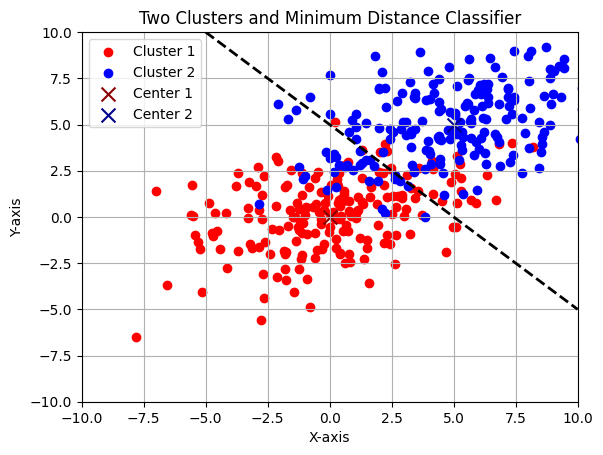

测试点 [2 2] 被分类到簇 1


In [19]:
import numpy as np
import matplotlib.pyplot as plt

def generate_clusters(mean1, mean2, cov, num_points=100):
    """
    生成两个数据簇。
    参数:
        mean1: 第一个簇的均值 (list or array)
        mean2: 第二个簇的均值 (list or array)
        cov: 协方差矩阵 (list or array)，假设两个簇相同
        num_points: 每个簇的点的数量
    返回:
        points1: 簇1的数据点
        points2: 簇2的数据点
    """
    points1 = np.random.multivariate_normal(mean1, cov, num_points)
    points2 = np.random.multivariate_normal(mean2, cov, num_points)
    return points1, points2

def plot_clusters(points1, points2, centers, decision_boundary):
    """
    绘制两个数据簇、簇中心以及分类边界。
    参数:
        points1: 簇1的数据点
        points2: 簇2的数据点
        centers: 两个簇的中心坐标
        decision_boundary: 分类边界函数
    """
    # 创建网格
    x_min, x_max = -10, 10
    y_min, y_max = -10, 10
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    # 计算每个网格点的分类
    distances = np.linalg.norm(grid - centers[0], axis=1) - np.linalg.norm(grid - centers[1], axis=1)
    predictions = distances.reshape(xx.shape)

    # 绘制分类边界
    plt.contour(xx, yy, predictions, levels=[0], colors='black', linewidths=2, linestyles='dashed', label='Decision Boundary')

    # 绘制数据点
    plt.scatter(points1[:, 0], points1[:, 1], c='red', label='Cluster 1')
    plt.scatter(points2[:, 0], points2[:, 1], c='blue', label='Cluster 2')

    # 绘制簇中心
    plt.scatter(centers[0][0], centers[0][1], c='darkred', s=100, marker='x', label='Center 1')
    plt.scatter(centers[1][0], centers[1][1], c='darkblue', s=100, marker='x', label='Center 2')

    # 图形美化
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.title('Two Clusters and Minimum Distance Classifier')
    plt.legend()
    plt.grid()
    plt.show()

def minimum_distance_classifier(point, center1, center2):
    """
    最小距离分类器：将点分类到最近的簇中心。
    参数:
        point: 要分类的点 (array)
        center1: 簇1的中心坐标
        center2: 簇2的中心坐标
    返回:
        label: 0 (簇1) 或 1 (簇2)
    """
    distance1 = np.linalg.norm(point - center1)
    distance2 = np.linalg.norm(point - center2)
    return 0 if distance1 < distance2 else 1

# 主程序
if __name__ == "__main__":
    # 生成两个数据簇
    mean1 = [0, 0]  # 簇1的中心
    mean2 = [5, 5]  # 簇2的中心
    cov = [[2, 4], [8, 2]]  # 协方差矩阵，方差为2，两个特征不相关

    points1, points2 = generate_clusters(mean1, mean2, cov, num_points=200)
    centers = [np.array(mean1), np.array(mean2)]

    # 可视化簇和分类边界
    plot_clusters(points1, points2, centers, minimum_distance_classifier)

    # 测试最小距离分类器
    test_point = np.array([2, 2])
    label = minimum_distance_classifier(test_point, centers[0], centers[1])
    print(f"测试点 {test_point} 被分类到簇 {label+1}")


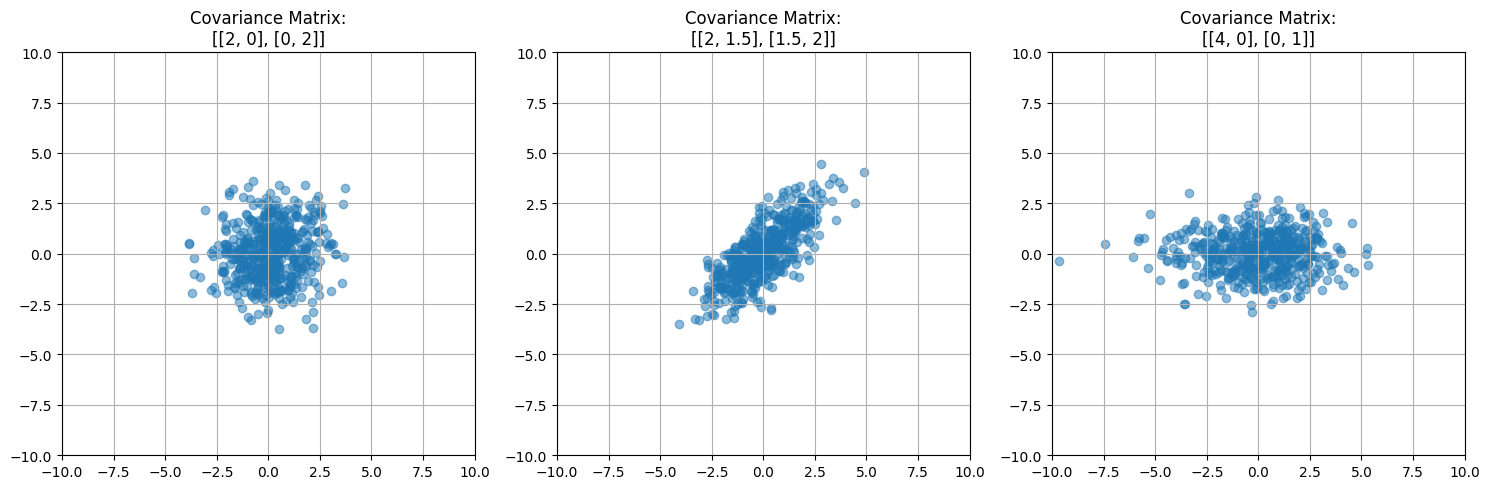

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 设置不同的协方差矩阵
covs = [
    [[2, 0], [0, 2]],     # 无相关性，方差相同（圆形）
    [[2, 1.5], [1.5, 2]], # 正相关性（椭圆形，沿对角线拉伸）
    [[4, 0], [0, 1]]      # x 方向方差大，y 方向方差小
]

# 数据均值
mean = [0, 0]

# 生成数据并绘制
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, cov in enumerate(covs):
    points = np.random.multivariate_normal(mean, cov, 500)
    axes[i].scatter(points[:, 0], points[:, 1], alpha=0.5)
    axes[i].set_title(f'Covariance Matrix:\n{cov}')
    axes[i].set_xlim(-10, 10)
    axes[i].set_ylim(-10, 10)
    axes[i].grid()

plt.tight_layout()
plt.show()


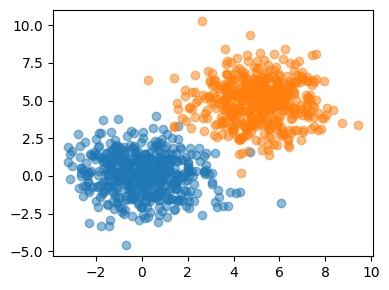

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# 设置不同的协方差矩阵
cov = [[2,0],[0,2]]

# 数据均值
mean1 = [0, 0]
mean2 = [5, 5]

# 生成数据并绘制
plt.figure(figsize=(4,3))
point1 = np.random.multivariate_normal(mean1, cov, 500)
point2 = np.random.multivariate_normal(mean2,cov,500)
plt.scatter(point1[:, 0], point1[:, 1], alpha=0.5)
plt.scatter(point2[:, 0], point2[:, 1], alpha=0.5)
plt.tight_layout()
plt.show()

In [103]:
import torch.nn as nn
import torch
import random

point1_ = []
point2_ = []

for i,temp in enumerate(point1) :
    point1_.append(np.insert(temp,2,1))
for i,temp in enumerate(point2) :
    point2_.append(np.insert(temp,2,0))
model = nn.Linear(2,1)

optimizer = torch.optim.SGD(model.parameters(),lr=0.01)

losser = nn.MSELoss()

epochs = 500
for epoch in range(epochs):
    for x1,x2 in zip(point1_,point2_):
        input_ = random.sample([x1,x2],1)[0]
        x,y = torch.tensor(input_[:2],dtype=torch.float32),torch.tensor(input_[-1],dtype=torch.float32)
        
        output_ = model(x)
        output_ = torch.sigmoid(output_)
        
        loss = losser(output_,y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
#         print(loss.item())
        

In [104]:
w = model.state_dict()['weight']
bias = model.state_dict()['bias']

w1 = np.array(-bias/w[0][0])
w2 = np.array(-bias/w[0][1])
w1,w2

(array([4.7237415], dtype=float32), array([4.78699], dtype=float32))

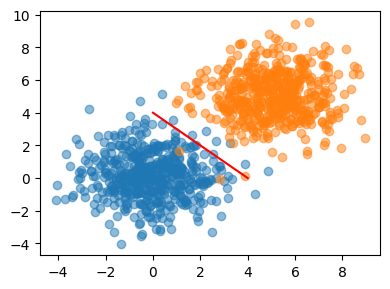

In [107]:
plt.figure(figsize=(4,3))

plt.plot([0,int(w1)],[int(w2),0],c='r')
point1 = np.random.multivariate_normal(mean1, cov, 500)
point2 = np.random.multivariate_normal(mean2,cov,500)
plt.scatter(point1[:, 0], point1[:, 1], alpha=0.5)
plt.scatter(point2[:, 0], point2[:, 1], alpha=0.5)

plt.tight_layout()
plt.show()
# print([0,0],[point1,point2])

In [17]:
import numpy as np

def convolve2d(image, kernel):
    """
    对输入图像进行2D卷积操作。

    参数:
        image: 输入的二维图像矩阵 (numpy数组)
        kernel: 卷积核/滤波器 (numpy数组)
    返回:
        result: 卷积后的图像矩阵 (numpy数组)
    """
    # 获取图像和卷积核的大小
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape
    
    # 计算输出图像的尺寸
    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1
    
    # 初始化输出图像
    result = np.zeros((output_height, output_width))
    
    # 翻转卷积核 (实现互相关运算)
    kernel_flipped = np.flipud(np.fliplr(kernel))
    
    # 执行卷积操作
    for i in range(output_height):
        for j in range(output_width):
            # 取当前窗口与卷积核相乘
            window = image[i:i+kernel_height, j:j+kernel_width]
            result[i, j] = np.sum(window * kernel_flipped)
    
    return result

# 输入图像
image = np.array([
    [90, 90, 5, 5, 50],
    [90, 90, 5, 5, 5],
    [60, 60, 60, 5, 5],
    [80, 80, 60, 50, 50],
    [80, 80, 60, 50, 50]
])

# 示例卷积核 (例如: 平均平滑核)
average_kernel = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

# 边缘检测卷积核 (Sobel 算子)
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# 执行卷积操作
result_avg = convolve2d(image, average_kernel)
result_sobel = convolve2d(image, sobel_x)

# 输出结果
print("输入图像:")
print(image)

print("\n使用平均平滑卷积核后的结果:")
print(np.round(result_avg, 2))

print("\n使用Sobel算子 (x方向) 卷积后的结果:")
print(result_sobel)


输入图像:
[[90 90  5  5 50]
 [90 90  5  5  5]
 [60 60 60  5  5]
 [80 80 60 50 50]
 [80 80 60 50 50]]

使用平均平滑卷积核后的结果:
[[61.11 36.11 16.11]
 [65.   46.11 27.22]
 [68.89 56.11 43.33]]

使用Sobel算子 (x方向) 卷积后的结果:
[[255. 310.  10.]
 [105. 225. 120.]
 [ 60. 145.  85.]]
